In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
# Importación de la librería específica para Boosting
from xgboost import XGBClassifier

In [2]:
# 1. Carga y Preparación del Dataset Transversal (oasis_cross-sectional.csv)
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de variables según informe clínico [12, informe_2]
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización de CDR (2 Clases) ---
# 0 = "non demented" (CDR 0), 1 = "demented" (CDR >= 0.5)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# 2. Tratamiento de Datos Faltantes (Requisito Sección 9 de la Guía)
# Aunque XGBoost maneja nulos, se imputa por mediana para asegurar consistencia
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:42:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ejecutando 10 iteraciones de validación independiente para XGBoost...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:42:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:42:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [02:42:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-d

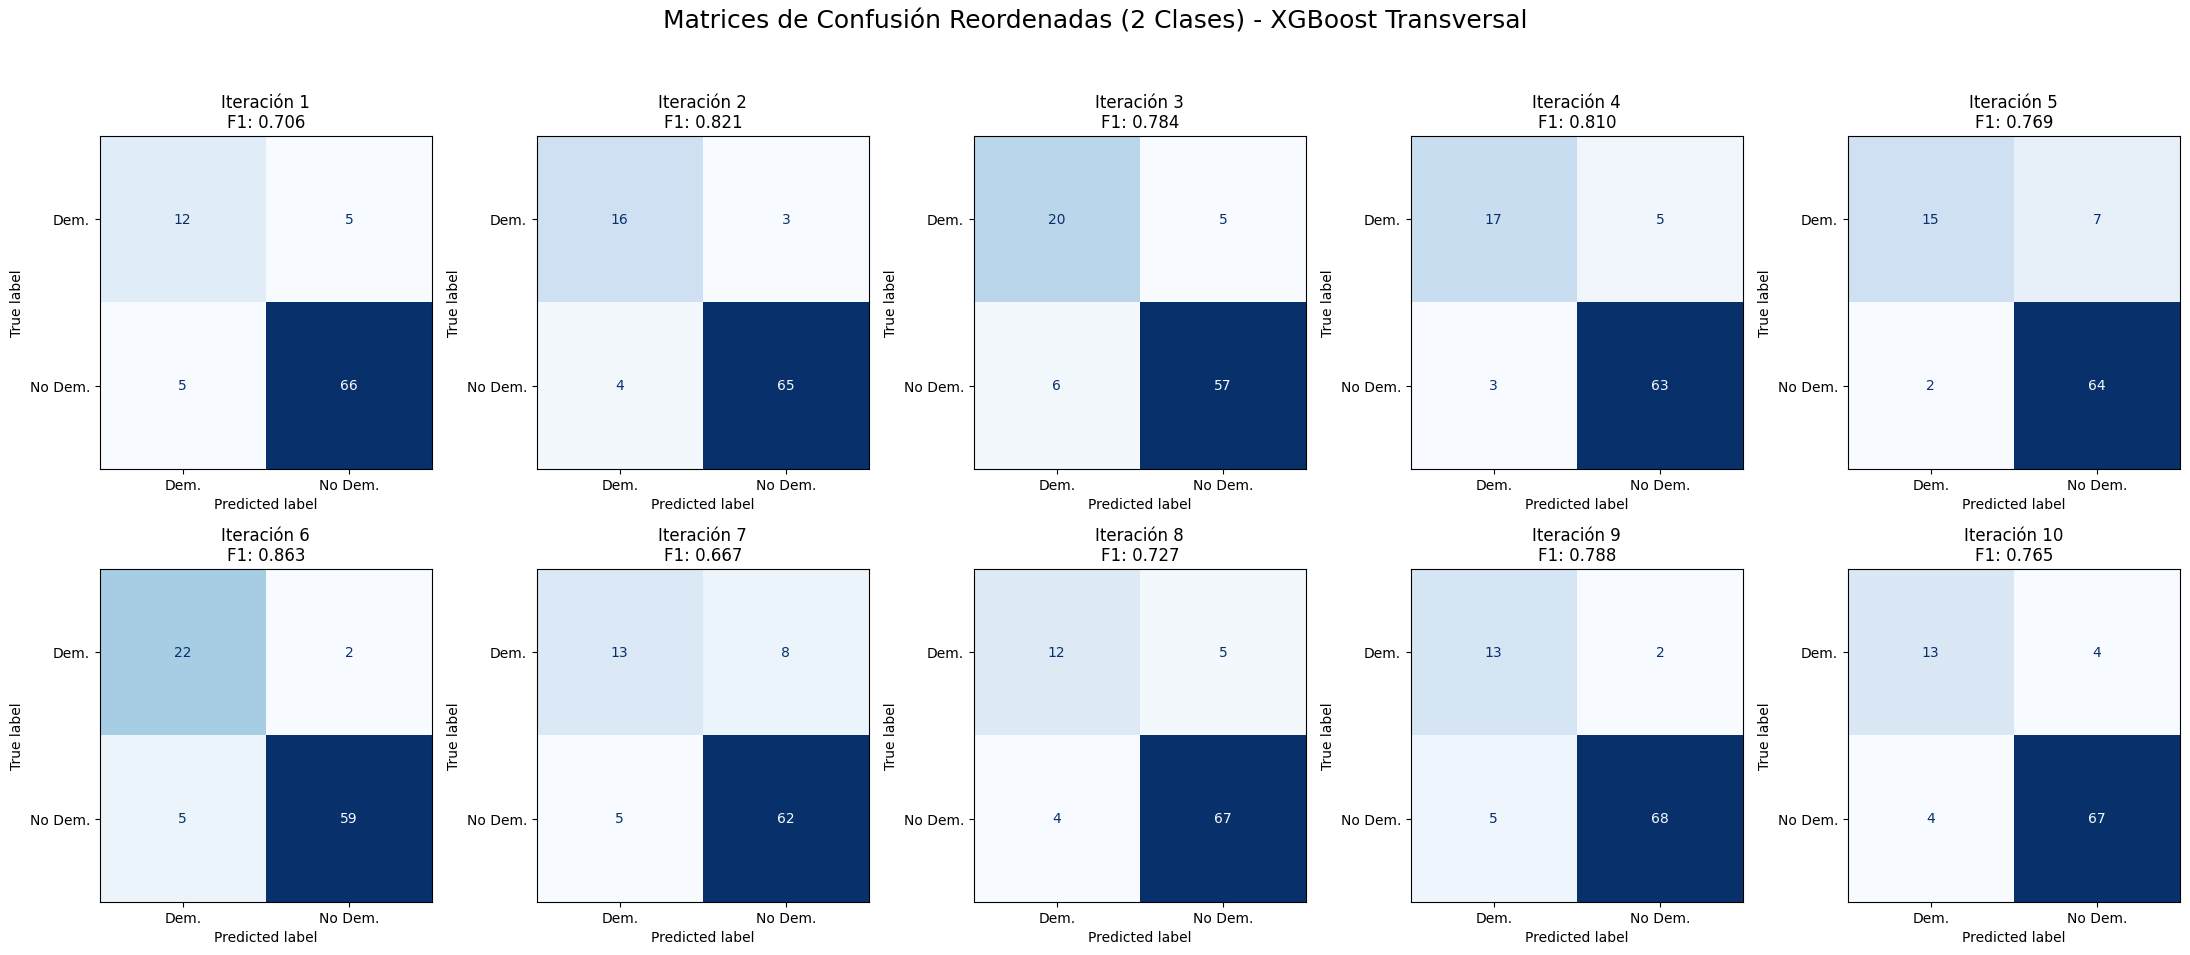


--- DESEMPEÑO FINAL XGBOOST (10 ITERACIONES) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8989 ± 0.0212
PREC                      | 0.7781 ± 0.0551
REC                       | 0.7676 ± 0.0870
F1                        | 0.7699 ± 0.0547
AUC                       | 0.9646 ± 0.0144


In [ ]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20 [Sección 12]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para XGBoost...")

for i in range(10):
    # Partición aleatoria única por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Implementación del Modelo XGBoost [Sección 11.7]
    # n_estimators: Número de árboles (100)
    # max_depth: Profundidad controlada para evitar sobreajuste (3)
    # learning_rate: Magnitud del ajuste en cada paso (0.1)
    # subsample: % de datos para entrenar cada árbol (0.8)
    xgb = XGBClassifier(n_estimators=100, 
                        max_depth=3, 
                        learning_rate=0.1, 
                        subsample=0.8, 
                        random_state=42,
                        use_label_encoder=False,
                        eval_metric='logloss')
    
    xgb.fit(X_train, y_train)
    
    # Predicciones
    y_pred = xgb.predict(X_test)
    y_proba = xgb.predict_proba(X_test)[:, 1]
    
    # 5. Registro de Métricas [Sección 13]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 6. Generación de Matrices de Confusión por iteración [Instrucción personalizada]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - XGBoost Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE) [Sección 12]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL XGBOOST (10 ITERACIONES) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)